<a href="https://colab.research.google.com/github/Tanwi20024/House_pricing_prediction/blob/main/House_pricing_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import all required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
# Upload the dataset to Colab
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [6]:
# Load the dataset
import pandas as pd

df = pd.read_csv('train.csv')

print(f"✅ Dataset loaded!")
print(f"   Rows    : {df.shape[0]}  (each row = one house)")
print(f"   Columns : {df.shape[1]}  (each column = one feature)")

✅ Dataset loaded!
   Rows    : 1460  (each row = one house)
   Columns : 81  (each column = one feature)


In [7]:
# See the first 5 rows of the dataset
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
# Check basic statistics of the price column
print("📊 Sale Price Statistics:")
print(df['SalePrice'].describe().round(0))
print(f"\nCheapest house : ${df['SalePrice'].min():,}")
print(f"Most expensive : ${df['SalePrice'].max():,}")
print(f"Average price  : ${df['SalePrice'].mean():,.0f}")

📊 Sale Price Statistics:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

Cheapest house : $34,900
Most expensive : $755,000
Average price  : $180,921


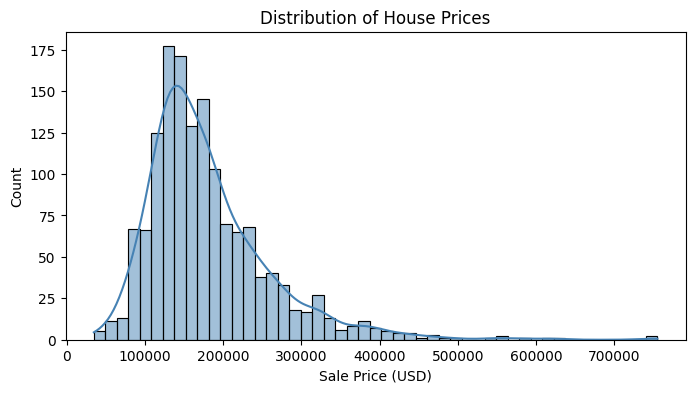

In [9]:
# Plot the distribution of house prices
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Sale Price (USD)')
plt.show()

In [10]:
# Select important features for our model
numeric_features = [
    'GrLivArea',       # SIZE     - Living area in sqft
    'TotalBsmtSF',     # SIZE     - Basement size in sqft
    '1stFlrSF',        # SIZE     - First floor sqft
    'BedroomAbvGr',    # ROOMS    - Number of bedrooms
    'FullBath',        # ROOMS    - Full bathrooms
    'HalfBath',        # ROOMS    - Half bathrooms
    'TotRmsAbvGrd',    # ROOMS    - Total rooms
    'GarageCars',      # Garage capacity
    'YearBuilt',       # Year built
    'OverallQual',     # Quality rating (1-10)
    'LotArea',         # Land size in sqft
]

categorical_features = ['Neighborhood']   # LOCATION

# Keep only selected columns + target
selected_cols = numeric_features + categorical_features + ['SalePrice']
data = df[selected_cols].copy()

print(f"✅ Features selected!")
print(f"   Total features : {len(numeric_features) + 1}")
print(f"   Dataset shape  : {data.shape}")

✅ Features selected!
   Total features : 12
   Dataset shape  : (1460, 13)


In [11]:
from sklearn.impute import SimpleImputer

# Fill missing values with median
imputer = SimpleImputer(strategy='median')
data[numeric_features] = imputer.fit_transform(data[numeric_features])

print("Missing values after fix:", data.isnull().sum().sum())
print("✅ Should be 0!")

Missing values after fix: 0
✅ Should be 0!


In [12]:
from sklearn.preprocessing import LabelEncoder

# Convert text → numbers
le = LabelEncoder()
data['Neighborhood'] = le.fit_transform(data['Neighborhood'].astype(str))

print("✅ Neighborhood encoded!")
print(data['Neighborhood'].unique()[:5])

✅ Neighborhood encoded!
[ 5 24  6 15 11]


In [13]:
import numpy as np

# Log transform SalePrice
data['SalePrice_log'] = np.log1p(data['SalePrice'])

print("✅ SalePrice log-transformed!")
print(f"Original range : ${data['SalePrice'].min():,} – ${data['SalePrice'].max():,}")
print(f"Log range      : {data['SalePrice_log'].min():.2f} – {data['SalePrice_log'].max():.2f}")

✅ SalePrice log-transformed!
Original range : $34,900 – $755,000
Log range      : 10.46 – 13.53


In [14]:
from sklearn.model_selection import train_test_split

# Define X (inputs) and y (target)
feature_cols = numeric_features + ['Neighborhood']

X = data[feature_cols]          # what we know about each house
y = data['SalePrice_log']       # what we want to predict

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split done!")
print(f"   Training houses : {len(X_train)}  (model learns from these)")
print(f"   Testing  houses : {len(X_test)}  (model is tested on these)")

✅ Data split done!
   Training houses : 1168  (model learns from these)
   Testing  houses : 292  (model is tested on these)


In [15]:
from sklearn.preprocessing import StandardScaler

# Scale all features to the same range
scaler = StandardScaler()

# Fit on training data ONLY, then apply to both
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ Scaling done!")
print(f"   Before scaling - GrLivArea max : {X_train['GrLivArea'].max()}")
print(f"   After scaling  - GrLivArea max : {X_train_sc[:, 0].max():.2f}")

✅ Scaling done!
   Before scaling - GrLivArea max : 5642.0
   After scaling  - GrLivArea max : 7.85


In [16]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train it on our training data
model.fit(X_train_sc, y_train)

print("✅ Model trained successfully!")
print(f"   Trained on : {len(X_train)} houses")

✅ Model trained successfully!
   Trained on : 1168 houses


In [17]:
import numpy as np

# Predict on test data
y_pred_log = model.predict(X_test_sc)

# Convert back from log scale to real price
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("✅ Predictions made!")
print(f"   First 5 actual prices    : {[f'${p:,.0f}' for p in y_true.values[:5]]}")
print(f"   First 5 predicted prices : {[f'${p:,.0f}' for p in y_pred[:5]]}")

✅ Predictions made!
   First 5 actual prices    : ['$154,500', '$325,000', '$115,000', '$159,000', '$315,500']
   First 5 predicted prices : ['$137,349', '$291,092', '$121,428', '$154,705', '$300,455']


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate all 3 metrics
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print("📊 MODEL PERFORMANCE REPORT")
print("=" * 40)
print(f"MAE  : ${mae:,.0f}")
print(f"       (on average we're off by this amount)")
print(f"\nRMSE : ${rmse:,.0f}")
print(f"       (penalises bigger mistakes more)")
print(f"\nR²   : {r2:.4f}")
print(f"       (model explains {r2*100:.1f}% of price variation)")
print("=" * 40)

if r2 > 0.80:
    print("✅ Great model! R² above 0.80")
else:
    print("⚠️ Model needs improvement")

📊 MODEL PERFORMANCE REPORT
MAE  : $20,791
       (on average we're off by this amount)

RMSE : $31,702
       (penalises bigger mistakes more)

R²   : 0.8690
       (model explains 86.9% of price variation)
✅ Great model! R² above 0.80


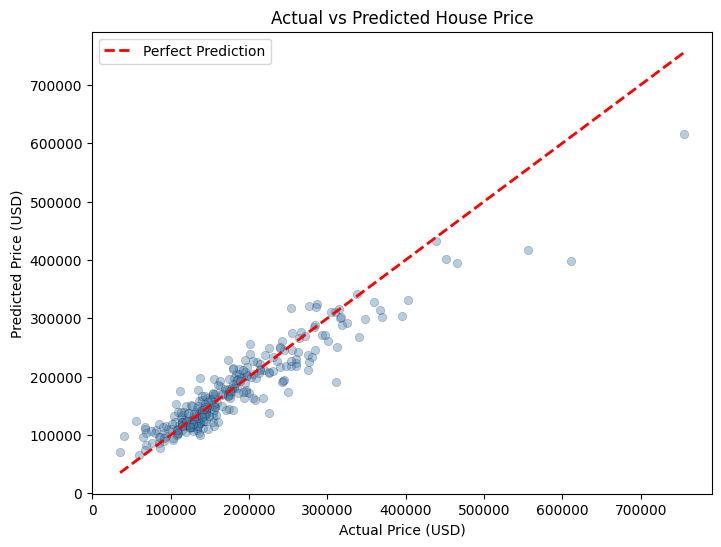

In [19]:
import matplotlib.pyplot as plt

# Actual vs Predicted chart
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.4, color='steelblue', edgecolors='k', linewidth=0.3)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted House Price')
plt.legend()
plt.show()

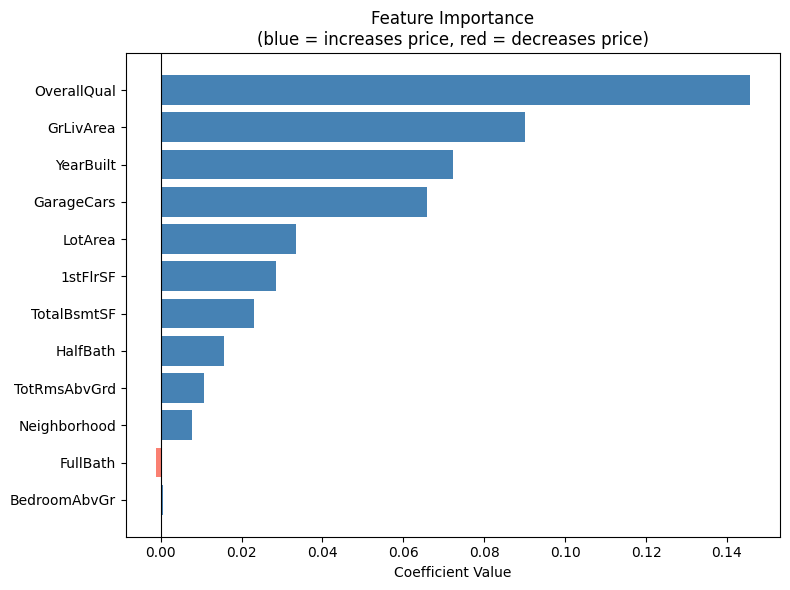

In [20]:
import pandas as pd

# Which features matter most?
coef_df = pd.DataFrame({
    'Feature'     : feature_cols,
    'Coefficient' : model.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']]

plt.figure(figsize=(8, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Importance\n(blue = increases price, red = decreases price)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import pandas as pd

# Define your own house details
my_house = pd.DataFrame([{
    'GrLivArea'    : 1500,   # Living area in sqft
    'TotalBsmtSF'  : 800,    # Basement size in sqft
    '1stFlrSF'     : 900,    # First floor sqft
    'BedroomAbvGr' : 3,      # Number of bedrooms
    'FullBath'     : 2,      # Full bathrooms
    'HalfBath'     : 1,      # Half bathrooms
    'TotRmsAbvGrd' : 7,      # Total rooms
    'GarageCars'   : 2,      # Garage capacity
    'YearBuilt'    : 2005,   # Year built
    'OverallQual'  : 7,      # Quality (1-10)
    'LotArea'      : 8000,   # Land size in sqft
    'Neighborhood' : 10,     # Location (encoded number)
}])

# Scale and predict
my_house_sc    = scaler.transform(my_house)
pred_log       = model.predict(my_house_sc)
predicted_price = np.expm1(pred_log)[0]

print("🏠 YOUR HOUSE DETAILS:")
print(f"   Bedrooms  : {my_house['BedroomAbvGr'].values[0]}")
print(f"   Bathrooms : {my_house['FullBath'].values[0]}")
print(f"   Size      : {my_house['GrLivArea'].values[0]} sqft")
print(f"   Year Built: {my_house['YearBuilt'].values[0]}")
print(f"   Quality   : {my_house['OverallQual'].values[0]}/10")
print(f"\n💰 PREDICTED PRICE: ${predicted_price:,.0f}")

🏠 YOUR HOUSE DETAILS:
   Bedrooms  : 3
   Bathrooms : 2
   Size      : 1500 sqft
   Year Built: 2005
   Quality   : 7/10

💰 PREDICTED PRICE: $197,927


In [22]:
import pickle

# Save the model and scaler to files
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as house_price_model.pkl")
print("✅ Scaler saved as scaler.pkl")

✅ Model saved as house_price_model.pkl
✅ Scaler saved as scaler.pkl


In [23]:
from google.colab import files

# Download both files
files.download('house_price_model.pkl')
files.download('scaler.pkl')

print("✅ Files downloaded to your computer!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded to your computer!
